In [37]:
import random
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.font_manager as fm


In [38]:
fontF = "C:\Windows\Fonts\gulim.ttc"
fontN = fm.FontProperties(fname=fontF, size= 10).get_name() # 폰트명
plt.rc("font", family=fontN) # mpl 기본톤프 바꾸기
plt.rcParams["axes.unicode_minus"]=False # - 안깨지게... 

In [39]:
def monte_carlo_simulation(
    revenue: list,
    cost: float,
    salary: float,
    rent: float = 0,
    admin: float = 0,
    fee: float = 0,
    tax_rate: float = 0.2
) -> dict:
    iterations = 10000
    results = []


    if len(revenue) == 1:
        for _ in range(iterations):
            simulated_revenue = random.gauss(revenue[0], revenue[0] * 0.1)
            simulated_cost = random.gauss(cost, cost * 0.1)
            gross_profit = simulated_revenue - simulated_cost - salary - rent - admin - fee
            net_profit = gross_profit * (1 - tax_rate)
            results.append(net_profit)
    else:
        for _ in range(iterations):
            simulated_revenue = random.choice(revenue)
            simulated_cost = random.gauss(cost, cost * 0.1)
            gross_profit = simulated_revenue - simulated_cost - salary - rent - admin - fee
            net_profit = gross_profit * (1 - tax_rate)
            results.append(net_profit)


####################################

    avg_profit = sum(results) / iterations
    losses = [r for r in results if r < 0]
    profits = [r for r in results if r >= 0]
    loss_probability = len(losses) / iterations
    ## loss prob 작성 개선
####################################
    ## 히스토그램 그래프 출력 >> matlab출력이기때문에, 이 "이미지" 부분의 전달방안을 고려해야됨.
    plt.figure(figsize=(8, 5))
    plt.hist(np.array(profits)/10000, bins=50, color="purple", alpha=0.7, edgecolor="black", label="이익 발생")
    plt.hist(np.array(losses)/10000, bins=50, color="red", alpha=0.7, edgecolor="black", label="손실 발생")
    plt.title("순이익 분포 (Monte Carlo Simulation)")
    plt.xlabel("순이익 (만원)")
    plt.ylabel("빈도")
    plt.axvline(avg_profit/10000, color="blue", linestyle="dashed", linewidth=2, label=f"평균: {avg_profit/10000:,.0f}만원")
    plt.legend()
    plt.show()

####################################
    return {
        "average_net_profit": avg_profit,
        "loss_probability": loss_probability
    }

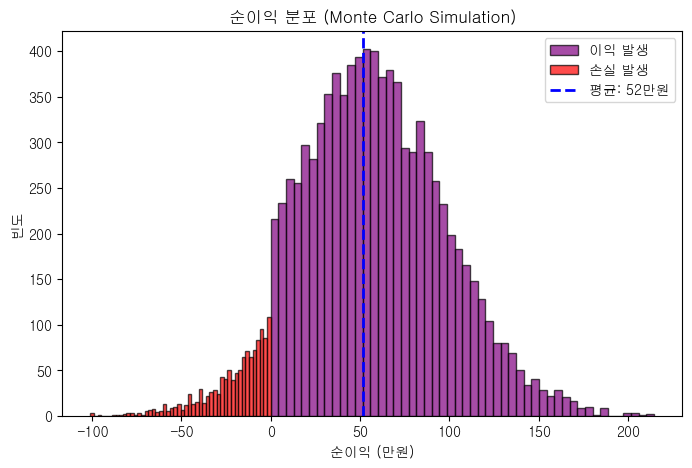

{'average_net_profit': 519199.90862472676, 'loss_probability': 0.1234}

In [45]:
monte_carlo_simulation([6000000],2000000,2000000,1000000,250000,0,0.3)